# DH 直线轨迹仿真与实机执行

目标：参考 `4、轨迹规划实操.ipynb` 的 `ctraj + ikine_LM` 方法，实现末端 DH 点从 `[100, 200, 200] mm` 到 `[100, 0, 200] mm` 的直线运动。

流程：

1. 用当前标准 DH 参数建立 `DFbot`。
2. 用 `rtb.tools.trajectory.ctraj(T_start, T_end, N_STEPS)` 生成笛卡尔直线轨迹。
3. 对每个轨迹点用 `DFbot.ikine_LM(..., q0=上一点, joint_limits=True)` 求逆解。
4. 用 `DFbot.plot(q_traj, movie=...)` 生成仿真动画。
5. 确认轨迹和关节角后，打开 `MOVE_REAL_ROBOT=True` 实机执行同一条关节轨迹。

注意：这里的坐标点是 DH 末端点，不一定是夹爪尖端/TCP。

轨迹点数: 40
起点目标 mm: [100, 200, 200]
终点目标 mm: [100, -100, 200]
起点关节角 deg: [57.77, -1.633, 67.897, 10.932, -5.121, 0.0]
终点关节角 deg: [-53.98, -5.354, 90.718, 20.802, -5.155, 0.0]
各关节角最小值 deg: [-53.98, -5.467, 67.897, 10.932, -9.068, 0.0]
各关节角最大值 deg: [57.77, -1.633, 98.185, 23.535, -5.121, 0.0]
最大位置误差 mm: 33.283924820039694
首末 FK 坐标 mm:
  start: [100.0, 200.0, 200.0]
  end  : [99.999, -100.0, 200.0]
[[ 57.77   -1.633  67.897  10.932  -5.121   0.   ]
 [ 57.709  -1.681  68.033  10.99   -5.146   0.   ]
 [ 57.524  -1.825  68.44   11.165  -5.222   0.   ]
 [ 57.21   -2.054  69.105  11.452  -5.344   0.   ]
 [ 56.762  -2.362  70.022  11.848  -5.513   0.   ]
 [ 56.169  -2.733  71.172  12.345  -5.725   0.   ]
 [ 55.418  -3.151  72.536  12.937  -5.975   0.   ]
 [ 54.49   -3.594  74.09   13.613  -6.259   0.   ]
 [ 53.363  -4.041  75.811  14.364  -6.571   0.   ]
 [ 52.006  -4.468  77.672  15.177  -6.904   0.   ]
 [ 50.382  -4.85   79.647  16.039  -7.251   0.   ]
 [ 48.44   -5.161  81.705  16.934  -7.602 

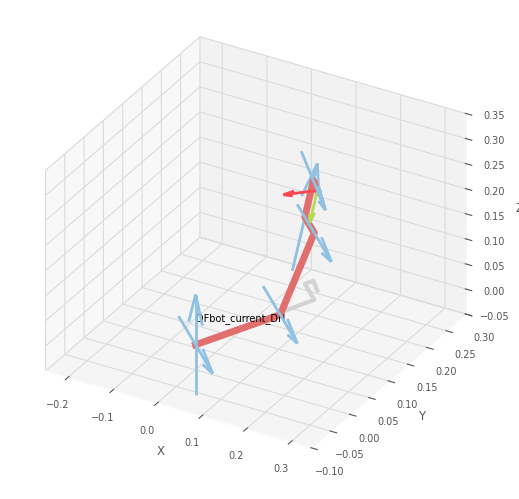

动画已生成: dh_line_100_200_200_to_100_0_200.gif


<Figure size 640x480 with 0 Axes>

In [13]:
import time
import numpy as np
import roboticstoolbox as rtb
from roboticstoolbox import DHRobot, RevoluteDH
from spatialmath import SE3
import arm_robot as robot

np.set_printoptions(precision=4, suppress=True)

# =====================
# 1. 直线轨迹配置
# =====================
START_POS_MM = [100, 200, 200]
END_POS_MM = [100, -100, 200]
N_STEPS = 40

# 位置-only 逆解：只强制末端坐标沿直线，不约束末端姿态。
# 若要同时约束姿态，改为 False，并设置 START_RPY_DEG / END_RPY_DEG。
POSITION_ONLY_IK = True
START_RPY_DEG = [0, 0, 0]  # roll, pitch, yaw，单位：度，仅 POSITION_ONLY_IK=False 时使用
END_RPY_DEG = [0, 0, 0]
RPY_ORDER = 'zyx'

# 逆解初值。位置-only 逆解不唯一，q0 会影响选到哪一支解。
# 建议优先填当前机械臂附近的关节角，减少实机运动跳变。
IK_Q0_DEG = [0, 40, 40, 0, 0, 0]

# 当前 notebook 使用的模型角范围，单位：度。RTB 逆解 joint_limits=True 会使用这里的范围。
MODEL_MIN_DEG = [-160, -40, -160, -160, -180, -180]
MODEL_MAX_DEG = [160, 180, 160, 160, 180, 180]

# 动画文件
MOVIE_PATH = 'dh_line_100_200_200_to_100_0_200.gif'
PLOT_LIMITS = [-0.25, 0.35, -0.10, 0.30, -0.05, 0.35]

# 实机执行配置。默认关闭，确认仿真和关节角后再改成 True。
MOVE_REAL_ROBOT = True
SERIAL_PORT = '/dev/ttyACM2'
UART_BAUDRATE = 115200

# tracking: 连续发送预计算关节轨迹，较适合近似直线轨迹。
# point: 每个轨迹点用梯形轨迹到位，运动更保守但会停顿。
REAL_EXECUTION_MODE = 'tracking'
REAL_DT = 0.2
REAL_SPEED = 2.0
REAL_ACCEL = 10.0


# =====================
# 2. 当前标准 DH 模型
# =====================
def build_dfbot():
    return DHRobot(
        [
            RevoluteDH(alpha=np.pi / 2, qlim=np.deg2rad([MODEL_MIN_DEG[0], MODEL_MAX_DEG[0]])),
            RevoluteDH(a=0.15, qlim=np.deg2rad([MODEL_MIN_DEG[1], MODEL_MAX_DEG[1]])),
            RevoluteDH(a=0.15, qlim=np.deg2rad([MODEL_MIN_DEG[2], MODEL_MAX_DEG[2]])),
            RevoluteDH(d=-0.05494, alpha=np.pi / 2, offset=np.pi / 2, qlim=np.deg2rad([MODEL_MIN_DEG[3], MODEL_MAX_DEG[3]])),
            RevoluteDH(d=0.068, alpha=-np.pi / 2, qlim=np.deg2rad([MODEL_MIN_DEG[4], MODEL_MAX_DEG[4]])),
            RevoluteDH(d=0.033, qlim=np.deg2rad([MODEL_MIN_DEG[5], MODEL_MAX_DEG[5]])),
        ],
        name='DFbot_current_DH',
    )


def check_model_limits(q_deg):
    q_deg = np.asarray(q_deg, dtype=float)
    lo = np.asarray(MODEL_MIN_DEG, dtype=float)
    hi = np.asarray(MODEL_MAX_DEG, dtype=float)
    bad = np.where((q_deg < lo) | (q_deg > hi))[0]
    if len(bad):
        detail = ', '.join(
            f'J{i + 1}: {q_deg[i]:.2f} not in [{lo[i]:.2f}, {hi[i]:.2f}]'
            for i in bad
        )
        raise ValueError('目标角度超过模型限位: ' + detail)


def pose_from_pos_rpy(pos_mm, rpy_deg):
    T = SE3.Trans(np.asarray(pos_mm, dtype=float) / 1000.0)
    if not POSITION_ONLY_IK:
        T = T * SE3.RPY(rpy_deg, unit='deg', order=RPY_ORDER)
    return T


DFbot = build_dfbot()
T_start = pose_from_pos_rpy(START_POS_MM, START_RPY_DEG)
T_end = pose_from_pos_rpy(END_POS_MM, END_RPY_DEG)

# 参考 4、轨迹规划实操.ipynb：用 ctraj 生成笛卡尔轨迹，再逐点 ikine_LM 求逆解。
cart_traj = rtb.tools.trajectory.ctraj(T_start, T_end, N_STEPS)
mask = [1, 1, 1, 0, 0, 0] if POSITION_ONLY_IK else [1, 1, 1, 1, 1, 1]

q_list = []
q_prev = np.deg2rad(np.asarray(IK_Q0_DEG, dtype=float))
for i, T_i in enumerate(cart_traj):
    sol = DFbot.ikine_LM(
        T_i,
        q0=q_prev,
        mask=mask,
        ilimit=100,
        slimit=100,
        joint_limits=True,
    )
    if not sol.success:
        raise RuntimeError(f'第 {i} 个轨迹点逆解失败: {getattr(sol, "reason", "")}; residual={getattr(sol, "residual", None)}')
    q_prev = sol.q
    q_list.append(sol.q)

q_traj = np.asarray(q_list)
q_traj_deg = np.rad2deg(q_traj)
check_model_limits(q_traj_deg.min(axis=0))
check_model_limits(q_traj_deg.max(axis=0))

# 检查 DH 末端实际走出的坐标是否是直线
fk_points_mm = np.asarray([DFbot.fkine(q).t * 1000 for q in q_traj])
target_points_mm = np.linspace(START_POS_MM, END_POS_MM, N_STEPS)
pos_err_mm = fk_points_mm - target_points_mm

print('轨迹点数:', N_STEPS)
print('起点目标 mm:', START_POS_MM)
print('终点目标 mm:', END_POS_MM)
print('起点关节角 deg:', np.round(q_traj_deg[0], 3).tolist())
print('终点关节角 deg:', np.round(q_traj_deg[-1], 3).tolist())
print('各关节角最小值 deg:', np.round(q_traj_deg.min(axis=0), 3).tolist())
print('各关节角最大值 deg:', np.round(q_traj_deg.max(axis=0), 3).tolist())
print('最大位置误差 mm:', float(np.max(np.linalg.norm(pos_err_mm, axis=1))))
print('首末 FK 坐标 mm:')
print('  start:', np.round(fk_points_mm[0], 3).tolist())
print('  end  :', np.round(fk_points_mm[-1], 3).tolist())

# 显示关节轨迹表，方便实机运行前检查
try:
    import pandas as pd
    display(pd.DataFrame(q_traj_deg, columns=[f'J{i}' for i in range(1, 7)]).round(3))
except Exception:
    print(np.round(q_traj_deg, 3))

# 生成动画。Notebook 内会显示 pyplot 动画；movie 文件保存到当前目录。
DFbot.plot(q_traj, backend='pyplot', movie=MOVIE_PATH, block=False, limits=PLOT_LIMITS)
print('动画已生成:', MOVIE_PATH)

## 实机执行直线轨迹

确认上面动画、关节角范围和首末坐标无误后，把第一个代码块里的 `MOVE_REAL_ROBOT` 改成 `True`，再运行下面单元。

In [14]:
def read_model_angles(ro):
    servo = ro.read_joints()
    if servo is False:
        return False, False
    return servo, ro.servo_to_model(servo)


if not MOVE_REAL_ROBOT:
    print('MOVE_REAL_ROBOT = False，未发送实机轨迹。确认动画和关节角后，改为 True 再运行本单元。')
else:
    check_model_limits(q_traj_deg.min(axis=0))
    check_model_limits(q_traj_deg.max(axis=0))

    ro = robot.arm_robot(
        L_p=0,
        L_p_mass_center=0,
        MAX_list_temp=MODEL_MAX_DEG,
        MIN_list_temp=MODEL_MIN_DEG,
        G_p=0,
        com=SERIAL_PORT,
        uart_baudrate=UART_BAUDRATE,
    )

    servo_before, model_before = read_model_angles(ro)
    print('model_before =', model_before)
    if model_before is False:
        raise RuntimeError('读取当前关节角失败，停止运动。')

    print('先运动到轨迹起点:', np.round(q_traj_deg[0], 3).tolist())
    ok = ro.set_arm_joints(angle_list=q_traj_deg[0].tolist(), speed=REAL_SPEED)
    if ok is False:
        raise RuntimeError('运动到轨迹起点失败。')
    ro.pose_done()
    time.sleep(0.5)

    if REAL_EXECUTION_MODE == 'tracking':
        # mode=0 是角度输入滤波/轨迹跟踪模式，param 是输入滤波带宽，需小于 300。
        bit_width = min(250, max(1, 1.0 / (2.0 * REAL_DT)))
        print('开始 tracking 执行，REAL_DT =', REAL_DT, 'bit_width =', bit_width)
        for q_deg in q_traj_deg:
            servo_target = ro.model_to_servo(q_deg.tolist())
            ro.set_angles(ro.ID_list, servo_target, speed=20, param=bit_width, mode=0)
            time.sleep(REAL_DT)
    elif REAL_EXECUTION_MODE == 'point':
        print('开始 point-to-point 执行')
        for q_deg in q_traj_deg:
            servo_target = ro.model_to_servo(q_deg.tolist())
            ro.set_angles(ro.ID_list, servo_target, speed=REAL_SPEED, param=REAL_ACCEL, mode=1)
            time.sleep(REAL_DT)
    else:
        raise ValueError("REAL_EXECUTION_MODE must be 'tracking' or 'point'")

    time.sleep(0.5)
    servo_after, model_after = read_model_angles(ro)
    print('model_after =', model_after)
    if model_after is not False:
        T_after = DFbot.fkine(np.deg2rad(model_after))
        print('按回读模型角计算的 DH 末端坐标 mm =', np.round(T_after.t * 1000, 3).tolist())

位置增益 P：10.0
积分增益 I：5.0
转速增益 D：0.550000011920929
机械臂第  1  号关节的 PID 修改为： [10.0, 5.0, 0.550000011920929]
位置增益 P：10.5600004196167
积分增益 I：4.949999809265137
转速增益 D：0.39100000262260437
机械臂第  2  号关节的 PID 修改为： [10.5600004196167, 4.949999809265137, 0.39100000262260437]
位置增益 P：10.5600004196167
积分增益 I：4.949999809265137
转速增益 D：0.39100000262260437
机械臂第  3  号关节的 PID 修改为： [10.5600004196167, 4.949999809265137, 0.39100000262260437]
位置增益 P：10.0
积分增益 I：9.0
转速增益 D：0.5
机械臂第  4  号关节的 PID 修改为： [10.0, 9.0, 0.5]
位置增益 P：12.0
积分增益 I：5.0
转速增益 D：0.10000000149011612
机械臂第  5  号关节的 PID 修改为： [12.0, 5.0, 0.10000000149011612]
位置增益 P：12.0
积分增益 I：5.0
转速增益 D：0.09600000083446503
机械臂第  6  号关节的 PID 修改为： [12.0, 5.0, 0.09600000083446503]
初始化成功
model_before = [-54.0, -5.4, 90.7, 20.8, -5.2, 0.0]
先运动到轨迹起点: [57.77, -1.633, 67.897, 10.932, -5.121, 0.0]
开始 tracking 执行，REAL_DT = 0.2 bit_width = 2.5
model_after = [-53.0, -5.3, 91.2, 21.0, -5.3, 0.0]
按回读模型角计算的 DH 末端坐标 mm = [100.324, -96.443, 199.938]


## 可选：回零

如需回到 `[0, 0, 0, 0, 0, 0]`，把 `MOVE_HOME = True` 后运行下面单元。

In [ ]:
MOVE_HOME = False
HOME_DEG = [0, 0, 0, 0, 0, 0]

if not MOVE_HOME:
    print('MOVE_HOME = False，未发送回零命令。')
else:
    home = np.asarray(HOME_DEG, dtype=float)
    check_model_limits(home)
    ro = robot.arm_robot(
        L_p=0,
        L_p_mass_center=0,
        MAX_list_temp=MODEL_MAX_DEG,
        MIN_list_temp=MODEL_MIN_DEG,
        G_p=0,
        com=SERIAL_PORT,
        uart_baudrate=UART_BAUDRATE,
    )
    print('model_before =', read_model_angles(ro)[1])
    ok = ro.set_arm_joints(angle_list=home.tolist(), speed=REAL_SPEED)
    print('command_ok =', ok)
    ro.pose_done()
    time.sleep(0.5)
    print('model_after =', read_model_angles(ro)[1])